# Margin Metric Tests

## Setup

### Imports

In [1]:
from pprint import pprint

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [2]:
%matplotlib inline

## Box in Box Margin Calculations


### Embedded Centred Cubes
- All margins are the same
- Expected Margin 1.0

![Embedded Boxes](<../../Images/FreeCAD Images/Embedded Boxes.png>)

In [3]:
def embedded_boxes_example():
    slice_spacing = 0.2
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = outer_cube + inner_cube + body
    return slice_data


slice_data = embedded_boxes_example()
embedded_box_structures = StructureSet(slice_data)
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')
assert relation_type .relation_type == 'CONTAINS'


INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube


In [4]:
# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = embedded_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Expected margins and comparison tolerance
tolerance = 0.1
expected_margins = {'x_neg': 1.0, 'x_pos': 1.0,
                    'y_neg': 1.0, 'y_pos': 1.0,
                    'z_neg': 1.0, 'z_pos': 1.0}
expected_minimum_margin = 1.0

for direction, expected_value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    actual_value = margin_result.orthogonal_margins[direction]
    assert abs(actual_value - expected_value) <= tolerance, \
        f"Expected {expected_value}±{tolerance} in {direction}, got {actual_value}."

assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
    f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}."

print("\n✓ Orthogonal margins match expected values within tolerance:")
pprint(margin_result.orthogonal_margins)
print(f"\n✓ Tolerance: ±{tolerance}")
print("✓ Minimum margin matches expected value within tolerance:")
pprint(margin_result.minimum_margin)

INFO:metrics.config:Loading metrics configuration from d:\OneDrive - Queen's University\Python\Projects\StructureRelations\src\metrics\metrics_config.json
INFO:metrics.config:Metrics configuration loaded successfully



✓ Orthogonal margins match expected values within tolerance:
{'x_neg': 1.0,
 'x_pos': 1.0,
 'y_neg': 1.0,
 'y_pos': 1.0,
 'z_neg': 1.0,
 'z_pos': 1.0}

✓ Tolerance: ±0.1
✓ Minimum margin matches expected value within tolerance:
np.float64(1.0)


### Embedded Box Shifted
- Different positive and negative X, Y, and Z Margins (Offset Cube in Cube)

![Embedded Boxes Shifted (Image not yet created)](<../../Images/FreeCAD Images/Embedded Boxes Shiufted.png>)

#### Embedded Boxes Shifted in Positive X, Y, and Z directions
- Expected Margins: 

|  Sign  |Direction|Margin|
|--------|---------|------|
|Positive|    X    | 0.5  |
|Negative|    X    | 5.5  |
|Positive|    Y    | 1.0  |
|Negative|    Y    | 5.0  |
|Positive|    Z    | 2.0  |
|Negative|    Z    | 4.0  |

In [5]:
slice_spacing = 0.1
tolerance = 0.1
# Outer Cube
outer_cube = make_box(roi_num=1, width=8, offset_x=0, offset_z=0,
                        spacing=slice_spacing)
inner_cube = make_box(roi_num=2, width=2, spacing=slice_spacing,
                        offset_x=2.5, offset_y=2, offset_z=1)
# combine the contours
slice_data = outer_cube + inner_cube

shifted_box_structures = StructureSet(slice_data)
shifted_box_structures.tolerance = tolerance
structure_a = shifted_box_structures.structures[1]
structure_b = shifted_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube


In [6]:
# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = shifted_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Expected margins and comparison tolerance
expected_margins = {
    'x_pos': 0.5,
    'x_neg': 5.5,
    'y_pos': 1.0,
    'y_neg': 5.0,
    'z_pos': 2.0,
    'z_neg': 4.0
    }
expected_minimum_margin = 0.5

for direction, expected_value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    actual_value = margin_result.orthogonal_margins[direction]
    assert abs(actual_value - expected_value) <= tolerance, \
        f"Expected {expected_value}±{tolerance} in {direction}, got {actual_value}."

assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
    f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}."

print("\n✓ Orthogonal margins match expected values within tolerance:")
pprint(margin_result.orthogonal_margins)
print(f"\n✓ Tolerance: ±{tolerance}")
print("✓ Minimum margin matches expected value within tolerance:")
pprint(margin_result.minimum_margin)


✓ Orthogonal margins match expected values within tolerance:
{'x_neg': 5.5,
 'x_pos': 0.5,
 'y_neg': 5.0,
 'y_pos': 1.0,
 'z_neg': 3.98,
 'z_pos': 1.98}

✓ Tolerance: ±0.1
✓ Minimum margin matches expected value within tolerance:
np.float64(0.5)


##### Example slice

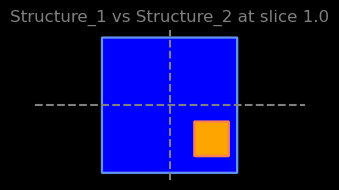

In [7]:
# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
slice_idx = 1.0
plot_roi_slice(shifted_box_structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax, tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()

#### Embedded Boxes Shifted in Negative X, Y, and Z directions
- Expected Margins: 

|  Sign  |Direction|Margin|
|--------|---------|------|
|Positive|    X    | 5.0  |
|Negative|    X    | 1.0  |
|Positive|    Y    | 4.0  |
|Negative|    Y    | 2.0  |
|Positive|    Z    | 5.5  |
|Negative|    Z    | 0.5  |

In [8]:
slice_spacing = 0.1
tolerance = 0.1
# Outer Cube
outer_cube = make_box(roi_num=1, width=8, offset_x=0, offset_z=0,
                        spacing=slice_spacing)
inner_cube = make_box(roi_num=2, width=2, spacing=slice_spacing,
                        offset_x=-2, offset_y=-1, offset_z=-2.5)
# combine the contours
slice_data = outer_cube + inner_cube

shifted_box_structures = StructureSet(slice_data)
shifted_box_structures.tolerance = tolerance
structure_a = shifted_box_structures.structures[1]
structure_b = shifted_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube


In [9]:
margin_result = shifted_box_structures.calculate_metric(1, 2, 'minimum_margins')
pprint(margin_result.orthogonal_margins)

{'x_neg': 1.0,
 'x_pos': 5.0,
 'y_neg': 2.0,
 'y_pos': 4.0,
 'z_neg': 0.48,
 'z_pos': 5.48}


In [10]:
# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = shifted_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Expected margins and comparison tolerance
expected_margins = {
    'x_pos': 5.0,
    'x_neg': 1.0,
    'y_pos': 4.0,
    'y_neg': 2.0,
    'z_pos': 5.5,
    'z_neg': 0.5
    }
expected_minimum_margin = 0.5

for direction, expected_value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    actual_value = margin_result.orthogonal_margins[direction]
    assert abs(actual_value - expected_value) <= tolerance, \
        f"Expected {expected_value}±{tolerance} in {direction}, got {actual_value}."
print("\n✓ Orthogonal margins match expected values within tolerance:")
pprint(margin_result.orthogonal_margins)
print(f"\n✓ Tolerance: ±{tolerance}")

#assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
#    f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}."
print("\nERROR: Minimum margin does not match expected value within tolerance:")
print(f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}.")
#pprint(margin_result.minimum_margin)


✓ Orthogonal margins match expected values within tolerance:
{'x_neg': 1.0,
 'x_pos': 5.0,
 'y_neg': 2.0,
 'y_pos': 4.0,
 'z_neg': 0.48,
 'z_pos': 5.48}

✓ Tolerance: ±0.1

ERROR: Minimum margin does not match expected value within tolerance:
Expected minimum margin 0.5±0.1, got 1.0.


### Squashed Box in Box
- Z Margin and Minimum Margin are distance between boundary slices 
- Expected Margins: 

|  Sign  |Direction|Margin|
|--------|---------|------|
|Positive|    X    | 1.0  |
|Negative|    X    | 1.0  |
|Positive|    Y    | 1.0  |
|Negative|    Y    | 1.0  |
|Positive|    Z    | 0.5  |
|Negative|    Z    | 0.5  |

In [11]:
slice_spacing = 0.1

# Centred boxes
squashed_outer_box = make_box(roi_num=1, width=4, length=4, height=3,
                              offset_x=0, offset_y=0, offset_z=0,
                              spacing=slice_spacing)
inner_cube = make_box(roi_num=2, width=2, offset_x=0, offset_y=0, offset_z=0,
                      spacing=slice_spacing)

# combine the contours
slice_data = squashed_outer_box + inner_cube

squashed_outer_box_example = StructureSet(slice_data)
structure_a = squashed_outer_box_example.structures[1]
structure_b = squashed_outer_box_example.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube


##### Boundary slices

In [12]:
slices = squashed_outer_box_example.slice_sequence.sequence
print(slices[~slices.Original])
#slices

           ThisSlice  NextSlice  PreviousSlice  Original
ThisSlice                                               
-1.525        -1.525       -1.5            NaN     False
-1.050        -1.050       -1.0           -1.1     False
 1.050         1.050        1.1            1.0     False
 1.525         1.525        NaN            1.5     False


In [13]:
# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = squashed_outer_box_example.calculate_metric(1, 2, 'minimum_margins')

# Expected margins and comparison tolerance
tolerance = 0.1
expected_margins = {
    'x_pos': 1.0,
    'x_neg': 1.0,
    'y_pos': 1.0,
    'y_neg': 1.0,
    'z_pos': 0.5,
    'z_neg': 0.5
    }
expected_minimum_margin = 0.5

for direction, expected_value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    actual_value = margin_result.orthogonal_margins[direction]
    assert abs(actual_value - expected_value) <= tolerance, \
        f"Expected {expected_value}±{tolerance} in {direction}, got {actual_value}."

print("\n✓ Orthogonal margins match expected values within tolerance:")
pprint(margin_result.orthogonal_margins)
print(f"\n✓ Tolerance: ±{tolerance}")

#assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
#    f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}."
print("\nERROR: Minimum margin does not match expected value within tolerance:")
print(f"Expected minimum margin {expected_minimum_margin}±{tolerance}, got {margin_result.minimum_margin}.")
#pprint(margin_result.minimum_margin)


✓ Orthogonal margins match expected values within tolerance:
{'x_neg': 1.0,
 'x_pos': 1.0,
 'y_neg': 1.0,
 'y_pos': 1.0,
 'z_neg': 0.47,
 'z_pos': 0.47}

✓ Tolerance: ±0.1

ERROR: Minimum margin does not match expected value within tolerance:
Expected minimum margin 0.5±0.1, got 1.0.
